In [1]:
# ══════════════════════════════════════════════════════════════
# CELL 1 — Install Dependencies
# ══════════════════════════════════════════════════════════════
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install",
                       "scikit-learn", "seaborn", "matplotlib",
                       "Pillow", "grad-cam", "-q"])
print("✅ Dependencies ready")

✅ Dependencies ready


In [2]:
# ══════════════════════════════════════════════════════════════
# CELL 2 — All Imports
# ══════════════════════════════════════════════════════════════
import torch
import torch.nn as nn
import torch.optim as optim
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, classification_report
from PIL import Image

print(f"✅ PyTorch version : {torch.__version__}")
print(f"✅ GPU available   : {torch.cuda.is_available()}")

✅ PyTorch version : 2.10.0+cpu
✅ GPU available   : False


In [3]:
# ══════════════════════════════════════════════════════════════
# CELL 3 — Configuration  ← EDIT THIS CELL ONLY
# ══════════════════════════════════════════════════════════════
TRAIN_DIR      = r"C:\Users\ACER\Desktop\rice_datasets\train"
VAL_DIR        = r"C:\Users\ACER\Desktop\rice_datasets\val"
OLD_MODEL_PATH = "resnet18_rice_v2.pth"    # your best saved model
NEW_MODEL_PATH = "resnet18_rice_v2.pth"    # saves here when improved
IMAGE_PATH     = "test.png"                # image to predict

IMG_SIZE       = 224
BATCH_SIZE     = 32
EXTRA_EPOCHS   = 10
CONF_THRESHOLD = 0.80

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Using device: {device}")

✅ Using device: cpu


In [4]:
# ══════════════════════════════════════════════════════════════
# CELL 4 — Transforms & Datasets
# ══════════════════════════════════════════════════════════════
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(degrees=45),
    transforms.ColorJitter(brightness=0.3,
                           contrast=0.3,
                           saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225])
])

val_test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                          std=[0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(root=TRAIN_DIR, transform=train_transforms)
val_dataset   = datasets.ImageFolder(root=VAL_DIR,   transform=val_test_transforms)

CLASS_NAMES = train_dataset.classes
NUM_CLASSES = len(CLASS_NAMES)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)

print(f"✅ Classes       : {CLASS_NAMES}")
print(f"✅ Train samples : {len(train_dataset)}")
print(f"✅ Val samples   : {len(val_dataset)}")

✅ Classes       : ['ClassA-Drought', 'ClassB-PestInfestation', 'ClassC-Healthy']
✅ Train samples : 1773
✅ Val samples   : 1773


In [5]:
# ══════════════════════════════════════════════════════════════
# CELL 5 — Load Saved Model + Apply All Fixes
# ══════════════════════════════════════════════════════════════
import os

# Build model architecture
model = models.resnet18(weights=None)
model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)

# Load saved weights if available
if os.path.exists(OLD_MODEL_PATH):
    checkpoint = torch.load(OLD_MODEL_PATH, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    print(f"✅ Loaded saved model from: {OLD_MODEL_PATH}")
else:
    print(f"⚠️  No saved model found at {OLD_MODEL_PATH}")
    print("   Loading fresh ImageNet weights instead")
    model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
    model.fc = nn.Linear(model.fc.in_features, NUM_CLASSES)

model = model.to(device)

# ── FIX 1: Unfreeze layer3, layer4, fc ─────────────────────
for name, param in model.named_parameters():
    if "layer3" in name or "layer4" in name or "fc" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False
print("✅ Fix 1: Unfroze layer3, layer4, fc")

# ── FIX 2: Class weights ────────────────────────────────────
class_weights = torch.tensor([1.0, 2.0, 1.5]).to(device)
criterion     = nn.CrossEntropyLoss(weight=class_weights)
print("✅ Fix 2: Class weights applied (Pest=2.0x, Healthy=1.5x)")

# ── FIX 3: Layered optimizer ────────────────────────────────
optimizer = optim.Adam([
    {"params": model.layer3.parameters(), "lr": 1e-5},
    {"params": model.layer4.parameters(), "lr": 1e-4},
    {"params": model.fc.parameters(),     "lr": 1e-3},
])
print("✅ Fix 3: Layered optimizer ready")
print("\n🚀 All fixes applied — ready to train!")

⚠️  No saved model found at resnet18_rice_v2.pth
   Loading fresh ImageNet weights instead
✅ Fix 1: Unfroze layer3, layer4, fc
✅ Fix 2: Class weights applied (Pest=2.0x, Healthy=1.5x)
✅ Fix 3: Layered optimizer ready

🚀 All fixes applied — ready to train!


In [6]:
# ══════════════════════════════════════════════════════════════
# CELL 6 — Training Loop
# ══════════════════════════════════════════════════════════════
best_val_acc = 0.9718   # V2 best result so far

for epoch in range(EXTRA_EPOCHS):
    print(f"Epoch {epoch+1}/{EXTRA_EPOCHS}")
    print("-" * 30)
    start_time = time.time()

    # ── TRAIN ──
    model.train()
    running_train_loss = 0.0
    correct_train = 0
    total_train   = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_train_loss += loss.item() * inputs.size(0)
        _, predicted   = torch.max(outputs, 1)
        total_train   += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    epoch_train_loss = running_train_loss / len(train_dataset)
    epoch_train_acc  = correct_train / total_train

    # ── VALIDATE ──
    model.eval()
    running_val_loss = 0.0
    correct_val = 0
    total_val   = 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss    = criterion(outputs, labels)
            running_val_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total_val   += labels.size(0)
            correct_val += (predicted == labels).sum().item()

    epoch_val_loss = running_val_loss / len(val_dataset)
    epoch_val_acc  = correct_val / total_val
    elapsed        = time.time() - start_time

    print(f"Train Loss: {epoch_train_loss:.4f} | Train Acc: {epoch_train_acc:.4f}")
    print(f"Val Loss:   {epoch_val_loss:.4f} | Val Acc:   {epoch_val_acc:.4f}")
    print(f"Time: {elapsed:.2f}s")

    # ── Auto save best model ────────────────────────────────
    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        torch.save({
            "model_state_dict"    : model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "class_names"         : CLASS_NAMES,
            "num_classes"         : NUM_CLASSES,
            "epoch"               : epoch + 1,
        }, NEW_MODEL_PATH)
        print(f"  ⭐ New best saved! Val Acc: {best_val_acc:.4f}")
    print()

print("✅ Training complete!")

Epoch 1/10
------------------------------
Train Loss: 0.1867 | Train Acc: 0.9425
Val Loss:   0.1080 | Val Acc:   0.9729
Time: 878.76s
  ⭐ New best saved! Val Acc: 0.9729

Epoch 2/10
------------------------------
Train Loss: 0.1100 | Train Acc: 0.9679
Val Loss:   0.0514 | Val Acc:   0.9836
Time: 867.96s
  ⭐ New best saved! Val Acc: 0.9836

Epoch 3/10
------------------------------
Train Loss: 0.0722 | Train Acc: 0.9803
Val Loss:   0.0534 | Val Acc:   0.9797
Time: 835.36s

Epoch 4/10
------------------------------
Train Loss: 0.0694 | Train Acc: 0.9780
Val Loss:   0.0291 | Val Acc:   0.9921
Time: 818.82s
  ⭐ New best saved! Val Acc: 0.9921

Epoch 5/10
------------------------------
Train Loss: 0.0442 | Train Acc: 0.9904
Val Loss:   0.0578 | Val Acc:   0.9757
Time: 766.32s

Epoch 6/10
------------------------------
Train Loss: 0.0283 | Train Acc: 0.9921
Val Loss:   0.0268 | Val Acc:   0.9898
Time: 798.67s

Epoch 7/10
------------------------------
Train Loss: 0.0317 | Train Acc: 0.9910
V

✅ Accuracy: 99.66%

                        precision    recall  f1-score   support

        ClassA-Drought       1.00      1.00      1.00       773
ClassB-PestInfestation       1.00      0.99      0.99       500
        ClassC-Healthy       0.99      1.00      0.99       500

              accuracy                           1.00      1773
             macro avg       1.00      1.00      1.00      1773
          weighted avg       1.00      1.00      1.00      1773



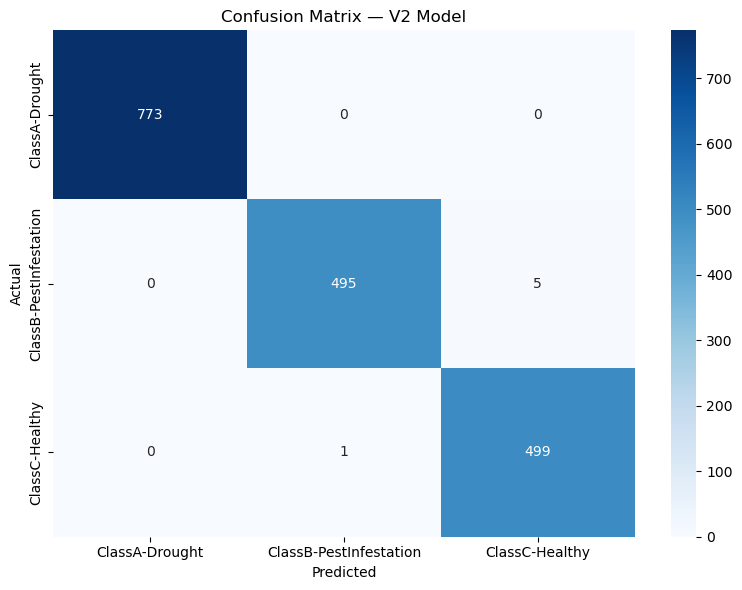


📊 Healthy vs Pest confusion:
   Healthy → wrongly Pest : 1  (target: <30)
   Pest → wrongly Healthy : 5  (target: <15)


In [7]:
# ══════════════════════════════════════════════════════════════
# CELL 7 — Evaluation + Confusion Matrix
# ══════════════════════════════════════════════════════════════
all_preds  = []
all_labels = []

model.eval()
with torch.no_grad():
    for inputs, labels in val_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs        = model(inputs)
        _, predicted   = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_acc = sum(p == l for p, l in zip(all_preds, all_labels)) / len(all_labels)
print(f"✅ Accuracy: {test_acc*100:.2f}%\n")
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title("Confusion Matrix — V2 Model")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

print("\n📊 Healthy vs Pest confusion:")
print(f"   Healthy → wrongly Pest : {cm[2][1]}  (target: <30)")
print(f"   Pest → wrongly Healthy : {cm[1][2]}  (target: <15)")

In [ ]:
# ══════════════════════════════════════════════════════════════
# CELL 8 — Predict Image with Confidence Threshold
# ══════════════════════════════════════════════════════════════
def predict_with_threshold(image_path, model, class_names, device,
                            threshold=CONF_THRESHOLD):
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ])
    image      = Image.open('test6.jpeg').convert("RGB")
    tensor     = transform(image).unsqueeze(0).to(device)
    model.eval()
    with torch.no_grad():
        outputs    = model(tensor)
        probs      = torch.softmax(outputs, dim=1)[0]
        confidence, predicted = torch.max(probs, 0)
    predicted_class = class_names[predicted.item()]
    conf_value      = confidence.item()
    plt.figure(figsize=(5, 5))
    plt.imshow(image)
    plt.axis("off")
    if conf_value < threshold:
        plt.title(
            f"⚠️ UNCERTAIN\nPossible: {predicted_class.upper()}\n"
            f"Confidence: {conf_value*100:.2f}% (below {threshold*100:.0f}%)\n"
            f"→ Recommend human review",
            fontsize=10, color="red", fontweight="bold"
        )
    else:
        plt.title(
            f"✅ Predicted: {predicted_class.upper()}\n"
            f"Confidence: {conf_value*100:.2f}%",
            fontsize=13, fontweight="bold"
        )
    plt.show()
    print("\n📊 All Probabilities:")
    for i, cls in enumerate(class_names):
        bar   = "█" * int(probs[i].item() * 30)
        alert = " ← top" if i == predicted.item() else ""
        print(f"  {cls:<25} {probs[i].item()*100:5.2f}%  {bar}{alert}")
    if conf_value < threshold:
        print(f"\n⚠️  Below {threshold*100:.0f}% threshold — recommend manual inspection")
    return predicted_class, conf_value

predict_with_threshold(IMAGE_PATH, model, CLASS_NAMES, device)

NameError: name 'test6' is not defined

In [ ]:
# ══════════════════════════════════════════════════════════════
# CELL 9 — Grad-CAM Heatmap
# ══════════════════════════════════════════════════════════════
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

def show_gradcam(image_path, model, class_names, device):
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ])
    image     = Image.open(image_path).convert("RGB")
    tensor    = transform(image).unsqueeze(0).to(device)
    rgb_image = np.array(image.resize((224, 224))) / 255.0
    model.eval()
    with torch.no_grad():
        outputs    = model(tensor)
        probs      = torch.softmax(outputs, dim=1)[0]
        confidence, predicted = torch.max(probs, 0)
    predicted_class = class_names[predicted.item()]
    target_layers = [model.layer4[-1]]
    cam           = GradCAM(model=model, target_layers=target_layers)
    targets       = [ClassifierOutputTarget(predicted.item())]
    grayscale_cam = cam(input_tensor=tensor, targets=targets)[0]
    visualization = show_cam_on_image(
        rgb_image.astype(np.float32), grayscale_cam, use_rgb=True
    )
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(image.resize((224, 224)))
    axes[0].set_title("Original Image", fontsize=12)
    axes[0].axis("off")
    axes[1].imshow(grayscale_cam, cmap="jet")
    axes[1].set_title("Grad-CAM Heatmap", fontsize=12)
    axes[1].axis("off")
    axes[2].imshow(visualization)
    axes[2].set_title(
        f"Overlay\nPredicted: {predicted_class.upper()}\n"
        f"Confidence: {confidence.item()*100:.2f}%", fontsize=12
    )
    axes[2].axis("off")
    plt.suptitle("Grad-CAM — What the model focuses on",
                 fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()
    print("\n📊 All Probabilities:")
    for i, cls in enumerate(class_names):
        bar = "█" * int(probs[i].item() * 30)
        print(f"  {cls:<25} {probs[i].item()*100:5.2f}%  {bar}")

show_gradcam(IMAGE_PATH, model, CLASS_NAMES, device)